# LLMs vs SLMs: Capability Gaps, Latency, Cost, and Use-Case Trade-Offs

## Introduction

Language Models (LMs) are AI systems trained to understand and generate human language.

Modern language models are generally categorized into:

- Large Language Models (LLMs)
- Small Language Models (SLMs)

Both are based on Transformer architectures but differ significantly in size, capabilities, computational requirements, and deployment scenarios.

---

# What are Large Language Models (LLMs)?

Large Language Models (LLMs) are models trained with billions or even trillions of parameters on massive datasets.

Examples:

- GPT
- LLaMA
- Claude
- Gemini

### Characteristics

- Very large parameter counts
- Broad knowledge and reasoning abilities
- Strong performance across many tasks
- Require substantial computing resources

---

# What are Small Language Models (SLMs)?

Small Language Models (SLMs) are compact language models designed to operate with fewer parameters and lower computational requirements.

Examples:

- Phi
- Gemma
- TinyLlama
- MobileBERT

### Characteristics

- Smaller parameter counts
- Faster inference
- Lower resource requirements
- Suitable for local deployment

# Capability Gaps

Capability refers to what a model can understand, reason about, and generate.

### LLM Capabilities

LLMs generally perform better at:

- Complex reasoning
- Multi-step problem solving
- Coding tasks
- Knowledge-intensive tasks
- Long-context understanding

### SLM Capabilities

SLMs perform well for:

- Simple conversations
- Classification tasks
- Basic question answering
- Lightweight assistants

---

### Example

Question:

```text
Explain how transformers use self-attention.
```

An LLM may provide a detailed technical explanation.

An SLM may provide a simpler and shorter response.

---

# Latency

Latency is the time required for a model to generate a response.

### Why Latency Matters

Users expect fast responses in:

- Chatbots
- Voice assistants
- Search systems
- Mobile applications

### LLM Latency

- Larger computations
- Slower responses
- More hardware requirements

### SLM Latency

- Faster responses
- Smaller computational load
- Better for real-time systems

---


### Trade-Off

Higher capability often leads to higher latency.

---

# Cost Comparison

Cost includes:

- Training cost
- Infrastructure cost
- Inference cost

---

## LLM Costs

Training requires:
- Massive datasets
- GPU clusters
- Large energy consumption

Inference requires:

- Powerful hardware
- Significant cloud resources

### Result

Higher operating costs.

---
## SLM Costs

Training requires:

- Smaller datasets
- Less compute power

Inference requires:

- Less memory
- Lower hardware requirements

### Result

Lower deployment and operational costs.

---



In [1]:
!pip install transformers torch sentencepiece accelerate -q



Importing required libraries

In [2]:
import torch
import time
import pandas as pd
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

c:\Users\Inspiron-3493\Desktop\pandas\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load SLM and LLM

In [3]:
slm_name = "distilgpt2"
llm_name = "gpt2-medium"

slm_tokenizer = AutoTokenizer.from_pretrained(slm_name)
slm_model = AutoModelForCausalLM.from_pretrained(slm_name)

llm_tokenizer = AutoTokenizer.from_pretrained(llm_name)
llm_model = AutoModelForCausalLM.from_pretrained(llm_name)

device = "cuda" if torch.cuda.is_available() else "cpu"

slm_model.to(device)
llm_model.to(device)

print("Models loaded on:", device)

c:\Users\Inspiron-3493\Desktop\pandas\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Inspiron-3493\.cache\huggingface\hub\models--distilgpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 76/76 [00:00<00:00, 17144.47it/s]
c:\Users\Inspiron-3493\Desktop\pandas\.

Models loaded on: cpu


Text Generation Function

In [4]:
def generate_text(model, tokenizer, prompt, max_length=80):

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    start = time.time()

    outputs = model.generate(
        **inputs,
        max_length=max_length,
        do_sample=True,
        temperature=0.7
    )

    end = time.time()

    text = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    latency = end - start

    return text, latency

Compare Responses

In [18]:
def generate_text(model, tokenizer, prompt, max_length=50):

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = model.generate(
        **inputs,
        max_length=max_length,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.eos_token_id
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

prompt = "Question: Explain internet in simlpe terms\nAnswer:"

slm_output = generate_text(slm_model, slm_tokenizer, prompt)
llm_output = generate_text(llm_model, llm_tokenizer, prompt)

print("SLM Output:\n", slm_output)
print("\nLLM Output:\n", llm_output)

SLM Output:
 Question: Explain internet in simlpe terms
Answer: Answer, yes!

LLM Output:
 Question: Explain internet in simlpe terms
Answer: The web is like a network of pipes, one pipe being the Internet. It's not just an open system where people can connect to each other and exchange information between computers but it also has


Latency Comparison Table

In [6]:
prompts = {
    "Simple":
    "Give three benefits of exercise.",

    "Medium":
    "Explain the difference between NLP and NLU.",

    "Complex":
    "Explain how Transformer models use self-attention and positional encoding."
}

slm_results = []
llm_results = []

for task, prompt in prompts.items():

    _, slm_latency = generate_text(
        slm_model,
        slm_tokenizer,
        prompt
    )

    _, llm_latency = generate_text(
        llm_model,
        llm_tokenizer,
        prompt
    )

    slm_results.append(slm_latency)
    llm_results.append(llm_latency)

comparison = pd.DataFrame({
    "Task": prompts.keys(),
    "SLM Latency": slm_results,
    "LLM Latency": llm_results
})

comparison

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


,Task,SLM Latency,LLM Latency
0,Simple,2.044330,26.977111
1,Medium,5.778585,17.422438
2,Complex,5.392159,15.148324


Latency Visualization

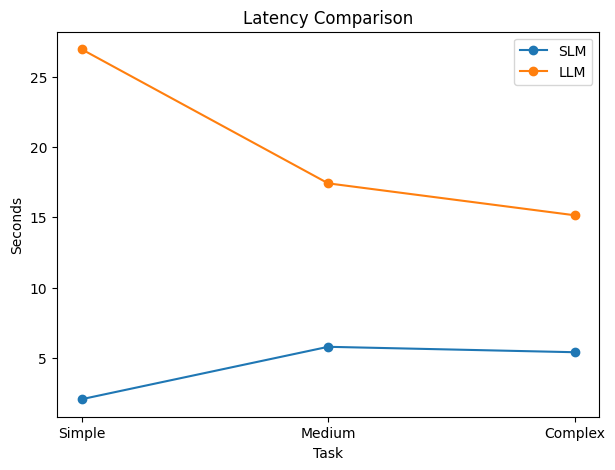

In [7]:
plt.figure(figsize=(7,5))

plt.plot(
    comparison["Task"],
    comparison["SLM Latency"],
    marker="o",
    label="SLM"
)

plt.plot(
    comparison["Task"],
    comparison["LLM Latency"],
    marker="o",
    label="LLM"
)

plt.title("Latency Comparison")
plt.xlabel("Task")
plt.ylabel("Seconds")
plt.legend()

plt.show()

Capability Comparison Table

In [8]:
capability = pd.DataFrame({
    "Factor": [
        "Reasoning",
        "Speed",
        "Cost",
        "Deployment",
        "Flexibility"
    ],

    "LLM": [
        "High",
        "Slow",
        "High",
        "GPU/Cloud",
        "Very High"
    ],

    "SLM": [
        "Medium",
        "Fast",
        "Low",
        "CPU/Edge",
        "Limited"
    ]
})

capability

,Factor,LLM,SLM
0,Reasoning,High,Medium
1,Speed,Slow,Fast
2,Cost,High,Low
3,Deployment,GPU/Cloud,CPU/Edge
4,Flexibility,Very High,Limited


Simple Routing System

In [9]:
def route_query(prompt):

    keywords = [
        "design",
        "architecture",
        "explain",
        "why",
        "how"
    ]

    if any(
        word in prompt.lower()
        for word in keywords
    ):
        return "LLM"

    return "SLM"

Test

In [21]:
queries = [
    "What is the capital of Nepal?",
    "Explain machine learning",
    "Design a scalable chatbot",
    "Tell me a joke",
    "Design a system"
]

for q in queries:

    print("Query:", q)
    print("Model:", route_query(q))
    print()

Query: What is the capital of Nepal?
Model: SLM

Query: Explain machine learning
Model: LLM

Query: Design a scalable chatbot
Model: LLM

Query: Tell me a joke
Model: SLM

Query: Design a system
Model: LLM



In [22]:
results = []

for q in queries:
    results.append({
        "Query": q,
        "Model Selected": route_query(q)
    })

import pandas as pd

pd.DataFrame(results)

,Query,Model Selected
0,What is the capital of Nepal?,SLM
1,Explain machine learning,LLM
2,Design a scalable chatbot,LLM
3,Tell me a joke,SLM
4,Design a system,LLM


# Real-World Applications

## LLM Applications

- ChatGPT-style assistants
- Content generation
- Code generation
- Research support
- Document analysis

---

## SLM Applications

- Mobile AI assistants
- Offline chatbots
- Smart devices
- On-device NLP
- Lightweight automation tools

---

# LLM vs SLM Comparison

| Feature | LLM | SLM |
|----------|----------|----------|
| Parameters | Very Large | Small |
| Reasoning | Excellent | Moderate |
| Knowledge | Broad | Limited |
| Latency | Higher | Lower |
| Cost | High | Low |
| Hardware Needs | Large | Small |
| Deployment | Cloud | Edge/Local |
| Text Quality | Excellent | Good |

---

# Key Learnings

- LLMs provide stronger reasoning and language capabilities.
- SLMs provide faster inference and lower deployment costs.
- Larger models require more computational resources.
- Smaller models are suitable for edge and mobile devices.
- Model selection depends on the trade-off between capability, speed, and cost.

---